### 1. Install Dependencies

In [1]:
!pip install -q transformers datasets sentence-transformers faiss-cpu torch xgboost scikit-learn numpy pandas tqdm rouge-score bitsandbytes accelerate groq

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.8/18.8 MB 34.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.1/43.1 MB 14.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.8/143.8 kB 5.4 MB/s eta 0:00:00


### 2. Imports and Environment

In [2]:
import os
import re
import time
import warnings
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from tqdm import tqdm
from google.colab import userdata

os.environ["TOKENIZERS_PARALLELISM"]  = "false"
os.environ["TF_CPP_MIN_LOG_LEVEL"]   = "3"
os.environ["TF_ENABLE_ONEDNN_OPTS"]  = "0"
os.environ["TRANSFORMERS_VERBOSITY"] = "error"
warnings.filterwarnings("ignore")

import torch
from transformers import (
    AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
)
from sentence_transformers import SentenceTransformer
from rouge_score import rouge_scorer as rouge_scorer_lib
from datasets import load_dataset
from groq import Groq

from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_auc_score, f1_score, brier_score_loss, accuracy_score
)

try:
    from xgboost import XGBClassifier
    HAS_XGB = True
except ImportError:
    HAS_XGB = False

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")
if device == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Device: cuda
GPU: Tesla T4


### 3. Configuration

This is to set up everything the pipeline needs before it runs the dataset, sample sizes, retrieval and generation limits, API keys for the three Groq judge accounts, cache file paths, and model identifiers. The random seed is fixed to ensure all sampling and model initialisation steps produce the same results every time.

In [3]:
RAGTRUTH_ID   = "wandb/RAGTruth-processed"
TASK_FILTER   = "QA"
N_TRAIN       = 200
N_TEST        = 100


TOP_K         = 3
MAX_NEW_TOK   = 100

GROQ_API_KEY_1 = userdata.get("GROQ_API_KEY_1")
GROQ_API_KEY_2 = userdata.get("GROQ_API_KEY_2")
GROQ_API_KEY_3 = userdata.get("GROQ_API_KEY_3")


TRAIN_CSV = "ragtruth_train_signals.csv"
TEST_CSV  = "ragtruth_test_signals.csv"


LLM_ID   = "Qwen/Qwen2.5-7B-Instruct"
EMBED_ID = "all-MiniLM-L6-v2"

SEED = 42
np.random.seed(SEED)

### 4. 3-Judge Ensemble for LLM-as-Judge Label Creation

Three separate Groq clients are initialised, one per account, each pointing to a different judge model from a different organisation GPT-oss-120b (OpenAI), GPT-oss-20b (OpenAI), and Qwen3.8-27b (Alibaba). Each judge independently evaluates whether a generated answer is faithful to the retrieved context, and the final label is determined by majority vote across the three responses, with rate limit handling and automatic retries built in for reliability.


In [4]:
groq_client_1 = Groq(api_key=GROQ_API_KEY_1)
groq_client_2 = Groq(api_key=GROQ_API_KEY_2)
groq_client_3 = Groq(api_key=GROQ_API_KEY_3)

JUDGE_SPECS = [
    ("GPT-oss-120b (OpenAI)",  groq_client_1, "openai/gpt-oss-120b"),
    ("GPT-oss-20b (OpenAI)",   groq_client_2, "openai/gpt-oss-20b"),
    ("Qwen3.8-27b (Alibaba)",  groq_client_3, "qwen/qwen3.8-27b"),
]


def _call_judge(client, model, prompt, max_retries=3):

    for attempt in range(max_retries):
        try:
            response = client.chat.completions.create(
                model=model,
                messages=[{"role": "user", "content": prompt}],
                temperature=0,
                max_tokens=1000
            )
            raw = response.choices[0].message.content.strip().upper()

            if "FAITHFUL" in raw:
                return 1
            elif "HALLUCINATED" in raw:
                return 0
            elif attempt < max_retries - 1:
                time.sleep(1)
                continue
            return -1

        except Exception as e:
            err = str(e)
            if "429" in err or "rate_limit" in err.lower():
                wait_match = re.search(r"try again in ([\d.]+)s", err)
                wait_time  = float(wait_match.group(1)) + 1.0                              if wait_match else 10
                print(f"  Rate limit ({model[:20]}) — waiting {wait_time:.1f}s...")
                time.sleep(wait_time)
                continue
            elif "day" in err.lower() and "limit" in err.lower():
                print(f"  Daily limit reached: {model[:30]}")
                return -1
            elif attempt < max_retries - 1:
                time.sleep(2 ** attempt)
            else:
                print(f"  Judge failed ({model[:30]}): {err[:60]}")
                return -1
    return -1


def llm_judge_faithfulness(generated_answer, context):
    prompt = (
        f"Retrieved context:\n{context[:600]}\n\n"
        f"Generated answer: {generated_answer}\n\n"
        f"Is the generated answer faithful to the retrieved context? "
        f"Faithful means the answer only contains information supported "
        f"by the context and does not add unsupported claims.\n"
        f"Reply with one word only: FAITHFUL or HALLUCINATED"
    )


    votes = [
        _call_judge(client, model, prompt)
        for _, client, model in JUDGE_SPECS
    ]

    valid = [v for v in votes if v != -1]

    if not valid:
        return -1

    faithful_votes = sum(valid)
    return 1 if faithful_votes > len(valid) / 2 else 0


print("Verifying 3 judges...")
test_prompt = (
    "Retrieved context:\nBagels stay fresh in an airtight container "
    "at room temperature.\n\n"
    "Generated answer: Keep bagels in a sealed container.\n\n"
    "Is the generated answer faithful to the retrieved context? "
    "Faithful means the answer only contains information supported "
    "by the context and does not add unsupported claims.\n"
    "Reply with one word only: FAITHFUL or HALLUCINATED"
)
for name, client, model in JUDGE_SPECS:
    v = _call_judge(client, model, test_prompt)
    status = "FAITHFUL ✓" if v == 1 else "HALLUCINATED ✗" if v == 0 else "FAILED ✗"
    print(f"  {name}: {status}")

Verifying 3 judges...
  GPT-oss-120b (OpenAI): FAITHFUL ✓
  GPT-oss-20b (OpenAI): FAITHFUL ✓
  Qwen3.8-27b (Alibaba): FAITHFUL ✓


### 5. Loading RAGTruth Dataset

Here we load the RAGTruth QA subset from HuggingFace, filter to good quality and non-duplicate examples only, and sample the required number of records for the specified split using the fixed random seed. Each record is returned with the query, up to three retrieved passages, and the full concatenated context ready for generation.

In [5]:
def load_ragtruth(n_samples, split="train"):

    print(f"  Loading RAGTruth {split} split ({TASK_FILTER} task)...")
    ds = load_dataset(RAGTRUTH_ID, split="train")
    df = ds.to_pandas()

    df = df[df["task_type"].str.upper() == TASK_FILTER.upper()]
    df = df[df["quality"] == "good"].reset_index(drop=True)
    df = df.drop_duplicates(subset=["query"]).reset_index(drop=True)


    df = df.sample(frac=1, random_state=SEED).reset_index(drop=True)
    if split == "train":
        df = df.iloc[:n_samples]
    else:
        df = df.iloc[N_TRAIN:N_TRAIN + n_samples]

    records = []
    for _, row in df.iterrows():
        context = str(row.get("context", ""))
        if not context.strip():
            continue
        passages = [p.strip() for p in context.split("\n\n") if p.strip()]
        if not passages:
            passages = [context]

        records.append({
            "query":         str(row.get("query", "")),
            "passages":      passages[:TOP_K],
            "context":       context
        })

    print(f"    Loaded {len(records)} records")
    return records

### 6. Signal Extraction Utilities

Here we define the three signal extraction functions that together produce the 17 features used by the calibration classifier. Generation signals are computed from the token-level log-probabilities and entropy values returned at each decoding step, retrieval signals are computed from the cosine similarity between the query and passage embeddings, and alignment signals measure lexical overlap, semantic similarity, and ROUGE-L between the generated answer and the retrieved context.

In [6]:
def _normalise(s):
    s = str(s).lower().strip()
    s = re.sub(r"[\W_]+", " ", s)
    return re.sub(r"\s+", " ", s).strip()


def compute_generation_signals(output, gen_ids):

    token_log_probs = []
    step_entropies  = []

    for i, step_logits in enumerate(output.scores):
        lp    = torch.nn.functional.log_softmax(step_logits[0], dim=-1)
        probs = torch.exp(lp)
        cid   = gen_ids[i] if i < len(gen_ids) else 0
        token_log_probs.append(lp[cid].item())
        valid = probs > 1e-10
        step_entropies.append(-(probs[valid] * lp[valid]).sum().item())

    pa  = np.exp(token_log_probs) if token_log_probs else np.array([0.5])
    t2m = 0.0
    if output.scores:
        fp  = torch.softmax(output.scores[0][0], dim=-1)
        t2  = torch.topk(fp, 2).values
        t2m = float((t2[0] - t2[1]).item())

    return {
        "entropy":             float(np.mean(step_entropies)) if step_entropies else 0.0,
        "avg_token_prob":      float(np.mean(pa)),
        "min_token_prob":      float(np.min(pa)),
        "var_token_prob":      float(np.var(pa)) if len(pa) > 1 else 0.0,
        "top2_margin":         t2m,
        "tail_prob":           float(np.mean(pa[-3:])) if len(pa) >= 3 else float(np.mean(pa)),
        "answer_length":       max(len(token_log_probs), 1),
        "answer_is_letter_only": 0,
    }


def compute_retrieval_signals(passages, query, embedder):

    if not passages:
        return {k: 0.0 for k in [
            "retriever_score","doc_similarity","ret_score_std",
            "ret_score_max","n_docs_retrieved","context_length"
        ]}
    q_emb  = embedder.encode([query], normalize_embeddings=True)
    p_embs = embedder.encode(passages, normalize_embeddings=True)
    scores = (p_embs @ q_emb.T).flatten()
    return {
        "retriever_score":  float(scores.max()),
        "doc_similarity":   float(scores.mean()),
        "ret_score_std":    float(scores.std()),
        "ret_score_max":    float(scores.max()),
        "n_docs_retrieved": len(passages),
        "context_length":   len(" ".join(passages).split()),
    }


def compute_alignment_signals(generated_answer, context_text, embedder):

    ctx_toks = set(context_text.lower().split())
    ans_toks = set(generated_answer.lower().split())
    overlap  = len(ctx_toks & ans_toks) / len(ans_toks) if ans_toks else 0.0

    try:
        ans_emb = embedder.encode([generated_answer], normalize_embeddings=True)
        ctx_emb = embedder.encode([context_text[:512]], normalize_embeddings=True)
        bs_f1   = float((ans_emb * ctx_emb).sum())
    except Exception:
        bs_f1 = 0.0

    try:
        scorer = rouge_scorer_lib.RougeScorer(["rougeL"], use_stemmer=True)
        rl = scorer.score(context_text[:512], generated_answer)["rougeL"].fmeasure
    except Exception:
        rl = 0.0

    return {
        "context_answer_overlap": overlap,
        "bertscore_f1":           bs_f1,
        "rouge_l":                rl,
    }


print("Signal utilities defined.")
print("  Retrieval  : 6 | Generation: 8 | Alignment: 3 = 17 total")

Signal utilities defined.
  Retrieval  : 6 | Generation: 8 | Alignment: 3 = 17 total


### 7. Feature Column Definition

Defines the 17 signal features passed to the calibration classifier: 6 retrieval, 8 generation, and 3 alignment and the name of the label column. Text columns such as the query and generated answer are intentionally excluded, ensuring the classifier learns from process signals only.

In [7]:
FEATURE_COLS = [
    "retriever_score",
    "doc_similarity",
    "ret_score_std",
    "ret_score_max",
    "n_docs_retrieved",
    "context_length",
    "entropy",
    "avg_token_prob",
    "min_token_prob",
    "var_token_prob",
    "top2_margin",
    "tail_prob",
    "answer_length",
    "answer_is_letter_only",
    "context_answer_overlap",
    "bertscore_f1",
    "rouge_l",
]

LABEL_COL = "reliability_label"

### 8. Load Models

Here we load the sentence embedder and the 4-bit quantised Qwen2.5-7B-Instruct generator only if the cached signal CSVs do not already exist, skipping this step entirely if both files are found. This avoids reloading the models unnecessarily when the pipeline is resumed after a partial run.

In [ ]:
need_pipeline = (
    not (TRAIN_CSV and os.path.exists(TRAIN_CSV)) or
    not (TEST_CSV  and os.path.exists(TEST_CSV))
)

if need_pipeline:
    print("Loading models...\n")

    print("[1] Sentence embedder (all-MiniLM-L6-v2)...")
    embedder = SentenceTransformer(EMBED_ID)

    print(f"\n[2] LLM: {LLM_ID} (4-bit quantised)...")
    quant_config = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_compute_dtype=torch.bfloat16,
        bnb_4bit_use_double_quant=True,
        bnb_4bit_quant_type="nf4"
    )
    tokenizer = AutoTokenizer.from_pretrained(LLM_ID)
    llm_model = AutoModelForCausalLM.from_pretrained(
        LLM_ID,
        quantization_config=quant_config,
        device_map="auto",
        low_cpu_mem_usage=True
    )
    llm_model.eval()
    tokenizer.pad_token = tokenizer.eos_token
    print(f"    VRAM: ~5GB (4-bit) | Device: {device}")
    print("\nAll models loaded.")

else:
    print("Both CSVs found — skipping model loading.")
    embedder = tokenizer = llm_model = None

Loading models...

[1] Sentence embedder (all-MiniLM-L6-v2)...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/243 [00:00<?, ?B/s]

    VRAM: ~5GB (4-bit) | Device: cuda

All models loaded.


### 9. Pipeline Functions

This is to setup the prompt builder which formats each query and its retrieved passages into Qwen2.5-7B-Instruct's chat template with a grounding instruction, and the main pipeline function which runs each record through retrieval signal extraction, answer generation, generation signal extraction, alignment signal extraction, and 3-judge faithfulness labelling in sequence. Rows where all three judges fail are dropped before saving, and all 17 signals along with the majority vote label are stored for each example.

In [8]:
def build_prompt(query, passages):

    context = "\n\n".join([f"Passage {i+1}: {p}"
                              for i, p in enumerate(passages)])[:3000]
    messages = [
        {
            "role": "system",
            "content": (
                "You are a helpful assistant. "
                "Answer the question based ONLY on the provided passages. "
                "Be concise and factual. "
                "Do not add information not present in the passages."
            ),
        },
        {
            "role": "user",
            "content": (
                f"Passages:\n{context}\n\n"
                f"Question: {query}\n\n"
                f"Answer:"
            ),
        },
    ]
    prompt_str = tokenizer.apply_chat_template(
        messages, add_generation_prompt=True, tokenize=False
    )
    inputs = tokenizer(
        prompt_str, return_tensors="pt",
        truncation=True, max_length=2048
    )
    return inputs["input_ids"]


def run_pipeline_on_records(records, desc="Processing"):
    rows          = []
    judge_failures = 0

    for rec in tqdm(records, desc=desc):
        query         = rec["query"]
        passages      = rec["passages"]
        context       = rec["context"]


        ret_sigs = compute_retrieval_signals(passages, query, embedder)


        input_ids      = build_prompt(query, passages).to(device)
        prompt_len     = input_ids.shape[1]
        attention_mask = torch.ones_like(input_ids)

        with torch.no_grad():
            output = llm_model.generate(
                input_ids,
                attention_mask=attention_mask,
                max_new_tokens=MAX_NEW_TOK,
                do_sample=False,
                output_scores=True,
                return_dict_in_generate=True,
                pad_token_id=tokenizer.eos_token_id,
            )

        gen_ids  = output.sequences[0][prompt_len:]
        gen_text = tokenizer.decode(gen_ids, skip_special_tokens=True).strip()

        gen_sigs = compute_generation_signals(output, gen_ids)
        gen_sigs["answer_is_letter_only"] = int(
            len(_normalise(gen_text).split()) <= 1
        )


        ali_sigs = compute_alignment_signals(gen_text, context, embedder)


        reliability_label = llm_judge_faithfulness(
            gen_text, context
        )
        if reliability_label == -1:
            judge_failures += 1

        rows.append({
            "query":            query,
            "generated_answer": gen_text,
            "context":          context[:600],
            **ret_sigs,
            **gen_sigs,
            **ali_sigs,
            "reliability_label": reliability_label,
        })

    df = pd.DataFrame(rows)

    failed = (df["reliability_label"] == -1).sum()
    if failed > 0:
        print(f"  Dropping {failed} rows (all judges failed)")
        df = df[df["reliability_label"] != -1].reset_index(drop=True)

    print(f"  Total judge failures: {judge_failures}")
    return df


print("Pipeline functions defined.")

Pipeline functions defined.


### 10. Delete Old CSVs

Deletes the cached signal CSV files to force the pipeline to rerun from scratch. Run this cell only when a fresh run is needed.

In [ ]:
for f in [TRAIN_CSV, TEST_CSV]:
    if os.path.exists(f):
        os.remove(f)
        print(f"Deleted: {f}")
    else:
        print(f"Not found: {f}")
print("Ready for fresh run.")

### 11. Run TRAIN Pipeline

This is to run the full pipeline on the training records, such as generation, signal extraction, and 3-judge faithfulness labelling to create the labelled training dataset for the calibration classifier, and saves it to CSV. If the CSV already exists from a previous run, it is loaded directly to avoid rerunning the pipeline.

In [ ]:
print("=" * 55)
print(f"TRAIN — {N_TRAIN} RAGTruth QA examples")
print("=" * 55)

if TRAIN_CSV and os.path.exists(TRAIN_CSV):
    print(f"[CACHE] Loading {TRAIN_CSV}")
    train_df = pd.read_csv(TRAIN_CSV)
    print(f"  Loaded {len(train_df)} rows")
else:
    train_records = load_ragtruth(N_TRAIN, split="train")
    train_df = run_pipeline_on_records(
        train_records, desc=f"Train ({N_TRAIN})"
    )
    train_df.to_csv(TRAIN_CSV, index=False)
    print(f"  Saved → {TRAIN_CSV}")

dist = train_df["reliability_label"].value_counts().to_dict()
print(f"\n  Label distribution (3-judge majority vote):")
print(f"  Faithful    : {dist.get(1,0)} ({dist.get(1,0)/len(train_df)*100:.1f}%)")
print(f"  Hallucinated: {dist.get(0,0)} ({dist.get(0,0)/len(train_df)*100:.1f}%)")

TRAIN — 200 RAGTruth QA examples
  Loading RAGTruth train split (QA task)...


README.md:   0%|          | 0.00/1.47k [00:00<?, ?B/s]

Repo card metadata block was not found. Setting CardData to empty.


data/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 22.3MB            

data/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

...

Generating train split:   0%|          | 0/15090 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2700 [00:00<?, ? examples/s]

    Loaded 200 records


Train (200): 100%|██████████| 200/200 [46:55<00:00, 14.08s/it]

  Total judge failures: 0
  Saved → ragtruth_train_signals.csv

  Label distribution (3-judge majority vote):
  Faithful    : 48 (24.0%)
  Hallucinated: 152 (76.0%)


### 12. Run TEST Pipeline

Runs the full pipeline on the held-out test records, such as generation, signal extraction, and 3-judge faithfulness labelling, to create the labelled test dataset for evaluating the calibration classifier, and saves it to CSV. The test split is kept completely separate from training and is never used during model training or hyperparameter selection.

In [ ]:
print("=" * 55)
print(f"TEST — {N_TEST} RAGTruth QA examples (held-out)")
print("=" * 55)

if TEST_CSV and os.path.exists(TEST_CSV):
    print(f"[CACHE] Loading {TEST_CSV}")
    test_df = pd.read_csv(TEST_CSV)
    print(f"  Loaded {len(test_df)} rows")
else:
    test_records = load_ragtruth(N_TEST, split="test")
    test_df = run_pipeline_on_records(
        test_records, desc=f"Test ({N_TEST})"
    )
    test_df.to_csv(TEST_CSV, index=False)
    print(f"  Saved → {TEST_CSV}")

dist = test_df["reliability_label"].value_counts().to_dict()
print(f"\n  Label distribution:")
print(f"  Faithful    : {dist.get(1,0)} ({dist.get(1,0)/len(test_df)*100:.1f}%)")
print(f"  Hallucinated: {dist.get(0,0)} ({dist.get(0,0)/len(test_df)*100:.1f}%)")

TEST — 100 RAGTruth QA examples (held-out)
  Loading RAGTruth test split (QA task)...


Repo card metadata block was not found. Setting CardData to empty.


    Loaded 100 records


Test (100): 100%|██████████| 100/100 [24:04<00:00, 14.44s/it]

  Total judge failures: 0
  Saved → ragtruth_test_signals.csv

  Label distribution:
  Faithful    : 18 (18.0%)
  Hallucinated: 82 (82.0%)


### 13. Load CSVs if Kernel Restarted

Reloads the train and test dataframes from the cached CSVs if they are not already in memory.

In [ ]:
import os, pandas as pd

if "train_df" not in dir():
    train_df = pd.read_csv(TRAIN_CSV)
    print(f"Loaded train_df: {len(train_df)} rows")

if "test_df" not in dir():
    test_df = pd.read_csv(TEST_CSV)
    print(f"Loaded test_df : {len(test_df)} rows")

print(f"Train faithful: {train_df['reliability_label'].sum()} "
      f"({train_df['reliability_label'].mean()*100:.1f}%)")
print(f"Test  faithful: {test_df['reliability_label'].sum()} "
      f"({test_df['reliability_label'].mean()*100:.1f}%)")

### 14. Signal Distributions

Here we compute the mean value of each of the 17 signals separately for faithful and hallucinated answers in the test set, and calculates the absolute difference Δ between the two groups to identify which signals are most discriminative. Signals with Δ greater than 0.05 are flagged as separating the two classes well, and the top 5 most discriminative signals are printed at the end.

In [10]:
print("SIGNAL DISTRIBUTIONS — TEST SET")
print("Label: 3-judge majority vote (1=faithful, 0=hallucinated)")
print("=" * 62)

feat_cols_present = [c for c in FEATURE_COLS if c in test_df.columns]
faithful     = test_df[test_df["reliability_label"] == 1]
hallucinated = test_df[test_df["reliability_label"] == 0]

print(f"  Faithful    : {len(faithful)}")
print(f"  Hallucinated: {len(hallucinated)}")
print()

if len(faithful) == 0 or len(hallucinated) == 0:
    print("  WARNING: All labels same class — check judge output.")
else:
    dist_rows = []
    for sig in feat_cols_present:
        f = faithful[sig].dropna()
        h = hallucinated[sig].dropna()
        if len(f) == 0 or len(h) == 0:
            continue
        d   = abs(f.mean() - h.mean())
        sep = "★ SEPARATES WELL" if d > 0.05 else "~ weak"
        dist_rows.append({
            "Signal": sig, "Faithful": f.mean(),
            "Hallucinated": h.mean(), "Delta": d, "Verdict": sep
        })
        print(f"  {sig:<26} F={f.mean():.4f}  H={h.mean():.4f}  "
              f"Δ={d:.4f}  {sep}")

    if dist_rows:
        dist_df = pd.DataFrame(dist_rows).sort_values("Delta", ascending=False)
        print(f"\n  Top 5 most discriminative signals:")
        print(dist_df[["Signal","Delta","Verdict"]].head(5).to_string(index=False))

SIGNAL DISTRIBUTIONS — TEST SET
Label: 3-judge majority vote (1=faithful, 0=hallucinated)
  Faithful    : 18
  Hallucinated: 82

  retriever_score            F=0.6775  H=0.7197  Δ=0.0422  ~ weak
  doc_similarity             F=0.5949  H=0.6475  Δ=0.0526  ★ SEPARATES WELL
  ret_score_std              F=0.0757  H=0.0643  Δ=0.0114  ~ weak
  ret_score_max              F=0.6775  H=0.7197  Δ=0.0422  ~ weak
  n_docs_retrieved           F=3.0000  H=3.0000  Δ=0.0000  ~ weak
  context_length             F=169.0556  H=259.6220  Δ=90.5664  ★ SEPARATES WELL
  entropy                    F=0.2698  H=0.2905  Δ=0.0208  ~ weak
  avg_token_prob             F=0.9022  H=0.8962  Δ=0.0060  ~ weak
  min_token_prob             F=0.3842  H=0.3379  Δ=0.0463  ~ weak
  var_token_prob             F=0.0261  H=0.0287  Δ=0.0026  ~ weak
  top2_margin                F=0.7063  H=0.8443  Δ=0.1380  ★ SEPARATES WELL
  tail_prob                  F=0.9226  H=0.8941  Δ=0.0285  ~ weak
  answer_length              F=60.0556  H=86

### 15. Sample Predictions

This is to print the first six examples from the test set showing the query, generated answer, majority vote label, and three key signal values such as entropy, context answer overlap, and retriever score to allow a quick qualitative check of the labels and signal behaviour before training the classifier.

In [11]:
print("SAMPLE PREDICTIONS — TEST SET")
print("=" * 62)

for _, row in test_df.head(6).iterrows():
    label = "FAITHFUL ✓" if row["reliability_label"] == 1 else "HALLUCINATED ✗"
    print(f"  [{label}]")
    print(f"  Q    : {str(row['query'])[:65]}")
    print(f"  Pred : {str(row['generated_answer'])[:60]}")
    print(f"  entropy={row['entropy']:.3f}  "
          f"overlap={row['context_answer_overlap']:.3f}  "
          f"retriever={row['retriever_score']:.3f}")
    print()

SAMPLE PREDICTIONS — TEST SET
  [HALLUCINATED ✗]
  Q    : how to make a chef hat in 2 minutes
  Pred : To make a chef hat quickly, follow these steps:

1. Prepare 
  entropy=0.240  overlap=0.755  retriever=0.510

  [HALLUCINATED ✗]
  Q    : why are greenhouse gases important to life on earth
  Pred : Greenhouse gases are important to life on Earth because they
  entropy=0.295  overlap=0.618  retriever=0.751

  [HALLUCINATED ✗]
  Q    : how to dehydrate meat for dogs in the oven
  Pred : Based on the provided passages, which do not specifically me
  entropy=0.377  overlap=0.561  retriever=0.481

  [HALLUCINATED ✗]
  Q    : how to make a horse stop kicking
  Pred : To make a horse stop kicking, you can:
- Tie a red ribbon in
  entropy=0.413  overlap=0.554  retriever=0.728

  [HALLUCINATED ✗]
  Q    : how to cook tenderloin in the oven
  Pred : To cook a tenderloin in the oven, preheat it to 475 degrees 
  entropy=0.276  overlap=0.727  retriever=0.773

  [HALLUCINATED ✗]
  Q    : how long

## 16. EDA

In [12]:
train_df.isnull().sum().sum()


np.int64(0)

There are no missing values in the dataset so no treatment is needed here.

In [13]:
train_df.dtypes

,0
query,object
generated_answer,object
context,object
retriever_score,float64
doc_similarity,float64
ret_score_std,float64
ret_score_max,float64
n_docs_retrieved,int64
context_length,int64
entropy,float64


All features in the dataset are numerical, so no additional preprocessing is required to handle the features. We are not using query,generated_answer and context.

In [14]:
train_df.duplicated().sum()

np.int64(0)

There are no duplicate values in the dataset.

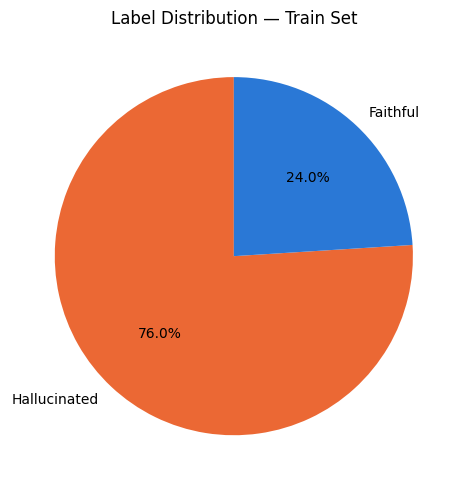

In [26]:
label_counts = train_df["reliability_label"].value_counts()

fig, ax = plt.subplots(figsize=(5, 5))
ax.pie(
    label_counts.values,
    labels=["Hallucinated", "Faithful"],
    colors=['#eb6834', '#2a78d6'],
    autopct='%1.1f%%',
    startangle=90
)
ax.set_title('Label Distribution — Train Set', fontsize=12)
plt.tight_layout()
plt.savefig('eda_label_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

The training set is imbalanced with approximately 76% hallucinated and 24% faithful examples, which will be handled during classifier training using class weighting.

## 17. Feature Engineering

Here we extract the 17 signal features and reliability labels from the train and test dataframes, drops any rows with missing values, and applies StandardScaler fitted on the training split only to standardise all features before classifier training.

In [15]:
feat_cols   = [c for c in FEATURE_COLS if c in train_df.columns
               and c in test_df.columns]
train_clean = train_df[feat_cols + [LABEL_COL]].dropna()
test_clean  = test_df[feat_cols  + [LABEL_COL]].dropna()

X_train = train_clean[feat_cols].values
y_train = train_clean[LABEL_COL].values
X_test  = test_clean[feat_cols].values
y_test  = test_clean[LABEL_COL].values

pos = int(y_train.sum())
neg = len(y_train) - pos

sc     = StandardScaler()
X_tr_s = sc.fit_transform(X_train)
X_te_s = sc.transform(X_test)

print(f"  Features : {len(feat_cols)}")
print(f"  Train    : {len(y_train)} | {pos} faithful ({y_train.mean()*100:.1f}%)")
print(f"  Test     : {len(y_test)}  | {int(y_test.sum())} faithful ({y_test.mean()*100:.1f}%)")

  Features : 17
  Train    : 200 | 48 faithful (24.0%)
  Test     : 100  | 18 faithful (18.0%)


## 19. Model Training

### Logistic Regression

Trains a logistic regression classifier using 5-fold cross-validation to select the best regularisation parameter C from the defined grid, with class weights balanced to handle the faithful/hallucinated class imbalance.

In [16]:
lr_params = {"C": [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]}

lr_grid = GridSearchCV(
    LogisticRegression(max_iter=3000, class_weight="balanced"),
    lr_params,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)
lr_grid.fit(X_tr_s, y_train)
best_lr       = lr_grid.best_estimator_
last_lr_coefs = best_lr.coef_[0]

print("Logistic Regression best parameters:", lr_grid.best_params_)
print("Logistic Regression best CV AUROC  :", round(lr_grid.best_score_, 4))

Logistic Regression best parameters: {'C': 1.0}
Logistic Regression best CV AUROC  : 0.8663


### MLP

Trains a multilayer perceptron classifier with ReLU activation using 5-fold cross-validation to select the best hidden layer architecture and regularisation strength from the defined grid.

The higher max_iter of 5000 ensures the network converges fully for each hyperparameter combination before evaluation.

In [17]:
mlp_params = {
    "hidden_layer_sizes": [(32,16),(64,32),(128,64),(256,128)],
    "alpha": [1e-5, 1e-4, 1e-3, 1e-2]
}

mlp_grid = GridSearchCV(
    MLPClassifier(max_iter=5000, random_state=SEED),
    mlp_params,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)
mlp_grid.fit(X_tr_s, y_train)
best_mlp = mlp_grid.best_estimator_

print("MLP best parameters:", mlp_grid.best_params_)
print("MLP best CV AUROC  :", round(mlp_grid.best_score_, 4))

MLP best parameters: {'alpha': 1e-05, 'hidden_layer_sizes': (128, 64)}
MLP best CV AUROC  : 0.8933


### Random Forest

Trains a Random Forest classifier using 5-fold cross-validation to select the best number of trees, maximum depth, and minimum samples per leaf from the defined grid.

Class weights are balanced to handle the class imbalance, and max_depth=None is included as an option to allow fully grown trees where the data supports it.

In [18]:
rf_params = {
    "n_estimators":    [100, 200, 300],
    "max_depth":       [3, 4, 5, None],
    "min_samples_leaf":[1, 2, 4]
}

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=SEED, class_weight="balanced"),
    rf_params,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)
rf_grid.fit(X_tr_s, y_train)
best_rf = rf_grid.best_estimator_

print("Random Forest best parameters:", rf_grid.best_params_)
print("Random Forest best CV AUROC  :", round(rf_grid.best_score_, 4))

Random Forest best parameters: {'max_depth': 4, 'min_samples_leaf': 4, 'n_estimators': 100}
Random Forest best CV AUROC  : 0.8729


### XGBoost

XGBoost is a gradient boosting alogrithm in which trees are built sequentially to correct the previous errors. It has a strong record of giving better performance on structured data.

5-fold cross-validation selects the best combination of tree count, depth, learning rate, and sampling ratios.

subsample and colsample_bytree are included to reduce overfitting by randomly sampling rows and features at each tree.

The scale_pos_weight parameter is set to the ratio of hallucinated to faithful examples so the model pays more attention to the minority faithful class during training.

In [19]:
xgb_params = {
    "n_estimators":    [200, 300, 500],
    "max_depth":       [3, 4, 5, 6],
    "learning_rate":   [0.01, 0.05, 0.1],
    "subsample":       [0.8, 1.0],
    "colsample_bytree":[0.8, 1.0]
}

xgb_grid = GridSearchCV(
    XGBClassifier(
        eval_metric="logloss", random_state=SEED,
        verbosity=0, scale_pos_weight=neg/max(pos,1)
    ),
    xgb_params,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)
xgb_grid.fit(X_tr_s, y_train)
best_xgb = xgb_grid.best_estimator_

print("XGBoost best parameters:", xgb_grid.best_params_)
print("XGBoost best CV AUROC  :", round(xgb_grid.best_score_, 4))

XGBoost best parameters: {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 500, 'subsample': 0.8}
XGBoost best CV AUROC  : 0.9044


## 20.Model Evaluation

Evaluates for the first time all four trained classifiers on the held out test set. The test set was never utilised in above operations of training or hyper parameter selection.

AUROC, F1 and accuracy is calculated for each model and kept for the results table.

Here the Logistic Regression coefficients are also stored for the feature importance analysis.

In [20]:
def evaluate_model(model_name, classifier):
    test_probs = classifier.predict_proba(X_te_s)[:,1]
    test_preds = classifier.predict(X_te_s)
    return {
        "Model":    model_name,
        "AUROC":    roc_auc_score(y_test, test_probs),
        "F1":       f1_score(y_test, test_preds, zero_division=0),
        "Accuracy": accuracy_score(y_test, test_preds)
    }

trained_models = {
    "Proposed: Logistic Regression": best_lr,
    "Proposed: MLP":                 best_mlp,
    "Proposed: Random Forest":       best_rf,
    "Proposed: XGBoost":             best_xgb,
}

model_results = {}
for name, clf in trained_models.items():
    model_results[name] = evaluate_model(name, clf)

last_lr_coefs = best_lr.coef_[0]

print("Model evaluation complete.")

Model evaluation complete.


## 21. Single-Signal Baselines Evaluation

Here we evaluates four single-signal baselines without any supervised training by normalising each signal to [0,1] using the training split range and using the normalised score directly as the predicted reliability probability. Entropy is inverted so that higher confidence maps to higher reliability, and AUROC is printed for each baseline to serve as the lower bound for the proposed classifiers.

In [21]:
baseline_specs = [
    ("Baseline: Entropy (inv.)",    "entropy",         True),
    ("Baseline: Avg Token Prob",    "avg_token_prob",  False),
    ("Baseline: BERTScore/Cosine",  "bertscore_f1",    False),
    ("Baseline: Retriever Score",   "retriever_score", False),
]

baseline_results = {}

for name, col, inv in baseline_specs:
    if col not in feat_cols:
        continue
    ci     = feat_cols.index(col)
    tr     = X_train[:, ci] * (-1 if inv else 1)
    te     = X_test[:,  ci] * (-1 if inv else 1)
    mn, mx = tr.min(), tr.max()
    probs  = np.clip((te - mn) / (mx - mn + 1e-9), 0, 1)
    preds  = (probs >= 0.5).astype(int)
    baseline_results[name] = {
        "AUROC":    roc_auc_score(y_test, probs),
        "F1":       f1_score(y_test, preds, zero_division=0),
        "Accuracy": accuracy_score(y_test, preds)
    }
    results = {**baseline_results, **model_results}

    print(f"  {name}: AUROC={baseline_results[name]['AUROC']:.4f}")

  Baseline: Entropy (inv.): AUROC=0.5481
  Baseline: Avg Token Prob: AUROC=0.5407
  Baseline: BERTScore/Cosine: AUROC=0.5474
  Baseline: Retriever Score: AUROC=0.4167


## 22. Results Table

Prints the full comparison table of all baselines and proposed model AUROCs against TPA white-box AUROC, and summarises the best baseline and best proposed model AUROCs, the improvement over the baseline and the gap with respect to TPA, and determines whether the framework matches or is better than the white-box state-of-the-art.

In [22]:
print("CALIBRATION MODEL RESULTS — HELD-OUT TEST SET")
print("=" * 70)
hdr = f"{'Model':<40} {'AUROC':>8} {'F1':>8} {'Acc':>8}"
print(hdr)
print("-" * 70)
print(f"{'TPA (2026) [white-box ref]':<40} {'0.824':>8} {'0.601':>8} {'N/A':>8}")
print("-" * 70)

for name, r in results.items():
    tag = " ←" if "Proposed" in name else ""
    print(f"{name:<40} {r['AUROC']:>8.3f} {r['F1']:>8.3f} "
          f"{r['Accuracy']:>8.3f}{tag}")

b_names = [n for n in baseline_results if n in results]
p_names = [n for n in model_results if n in results]
best_b  = max(b_names, key=lambda n: results[n]["AUROC"])
best_p  = max(p_names, key=lambda n: results[n]["AUROC"])
gap     = results[best_p]["AUROC"] - results[best_b]["AUROC"]
tpa_gap = results[best_p]["AUROC"] - 0.824

print(f"\n  Best baseline : {results[best_b]['AUROC']:.3f}")
print(f"  Best proposed : {results[best_p]['AUROC']:.3f}")
print(f"  vs baseline   : {gap:+.3f}")
print(f"  vs TPA        : {tpa_gap:+.3f}")

if tpa_gap >= 0:
    print(f"  ★ Matches or beats TPA without internal model access!")
elif tpa_gap > -0.05:
    print(f"  ✓ Within 5% of TPA — competitive black-box performance")
else:
    print(f"  △ Below TPA — gap attributable to black-box constraint")

CALIBRATION MODEL RESULTS — HELD-OUT TEST SET
Model                                       AUROC       F1      Acc
----------------------------------------------------------------------
TPA (2026) [white-box ref]                  0.824    0.601      N/A
----------------------------------------------------------------------
Baseline: Entropy (inv.)                    0.548    0.280    0.280
Baseline: Avg Token Prob                    0.541    0.283    0.290
Baseline: BERTScore/Cosine                  0.547    0.283    0.290
Baseline: Retriever Score                   0.417    0.267    0.340
Proposed: Logistic Regression               0.892    0.667    0.840 ←
Proposed: MLP                               0.890    0.683    0.870 ←
Proposed: Random Forest                     0.904    0.722    0.900 ←
Proposed: XGBoost                           0.890    0.579    0.840 ←

  Best baseline : 0.548
  Best proposed : 0.904
  vs baseline   : +0.356
  vs TPA        : +0.080
  ★ Matches or beats TPA 

## 23. Ablation Study

Here we run two analyses to understand signal contributions. First, print the absolute logistic regression coefficients for all 17 signals to show which features the classifier weights most. Second, trains a separate logistic regression on each of the signal groups alone for retrieval, generation and alignment and compares these individual AUROCs with the 17-signal combination to estimate the complementary value of combining all these three groups of signals.

In [24]:
print("ABLATION STUDY")
print("=" * 62)

if last_lr_coefs is not None:
    print("\n[1] Feature importance — LR |coefficient|")
    coefs = np.abs(last_lr_coefs)
    for feat, c in sorted(zip(feat_cols, coefs), key=lambda x: -x[1]):
        bar = "█" * int(c * 20 / (coefs.max() + 1e-9))
        print(f"  {feat:<26} {c:.4f}  {bar}")

print("\n[2] Signal group ablation (LR on each group separately)")

ret_f = [c for c in feat_cols if c in [
    "retriever_score","doc_similarity","ret_score_std",
    "ret_score_max","n_docs_retrieved","context_length"]]
gen_f = [c for c in feat_cols if c in [
    "entropy","avg_token_prob","min_token_prob","var_token_prob",
    "top2_margin","tail_prob","answer_length","answer_is_letter_only"]]
ali_f = [c for c in feat_cols if c in [
    "context_answer_overlap","bertscore_f1","rouge_l"]]

auroc_scores = {}

for gname, gcols, fig_key in [
    ("Retrieval only",  ret_f,     "Retrieval\nonly"),
    ("Generation only", gen_f,     "Generation\nonly"),
    ("Alignment only",  ali_f,     "Alignment\nonly"),
    ("All 17 combined", feat_cols, "All 17\ncombined"),
]:
    if not gcols:
        continue
    idxs = [feat_cols.index(c) for c in gcols]
    sc_g = StandardScaler()
    Xtr  = sc_g.fit_transform(X_train[:, idxs])
    Xte  = sc_g.transform(X_test[:, idxs])
    lr   = LogisticRegression(max_iter=3000, C=1.0, class_weight="balanced")
    lr.fit(Xtr, y_train)
    auc  = roc_auc_score(y_test, lr.predict_proba(Xte)[:,1])
    auroc_scores[fig_key] = auc
    print(f"  {gname:<28} AUROC = {auc:.3f}")

ABLATION STUDY

[1] Feature importance — LR |coefficient|
  answer_length              2.1106  ███████████████████
  rouge_l                    1.5965  ███████████████
  ret_score_std              0.9348  ████████
  context_answer_overlap     0.6811  ██████
  min_token_prob             0.6504  ██████
  entropy                    0.6165  █████
  bertscore_f1               0.3507  ███
  var_token_prob             0.3415  ███
  context_length             0.2871  ██
  avg_token_prob             0.2669  ██
  retriever_score            0.2650  ██
  ret_score_max              0.2650  ██
  doc_similarity             0.1428  █
  tail_prob                  0.1117  █
  top2_margin                0.0927  
  n_docs_retrieved           0.0000  
  answer_is_letter_only      0.0000  

[2] Signal group ablation (LR on each group separately)
  Retrieval only               AUROC = 0.801
  Generation only              AUROC = 0.782
  Alignment only               AUROC = 0.682
  All 17 combined            

## 24. Ablation Study Plot

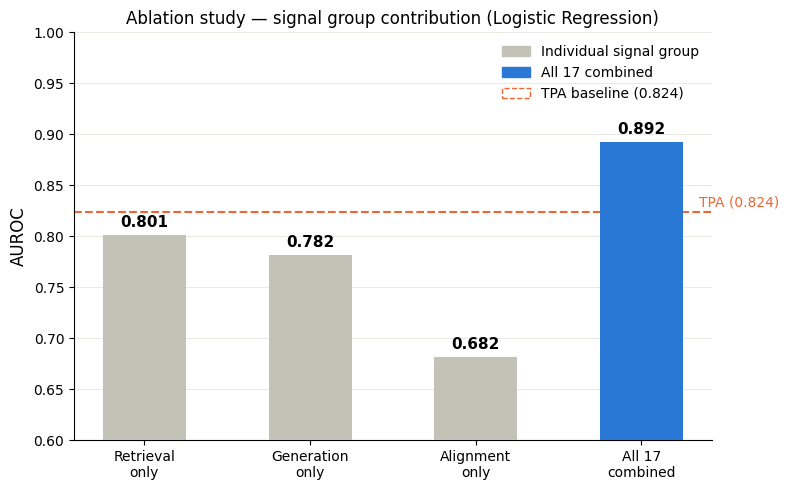

In [25]:
labels = list(auroc_scores.keys())
scores = list(auroc_scores.values())
colors = ['#c3c2b7', '#c3c2b7', '#c3c2b7', '#2a78d6']

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(labels, scores, color=colors, width=0.5, zorder=3)

ax.axhline(y=0.824, color='#eb6834', linestyle='--', linewidth=1.5)
ax.text(3.35, 0.829, 'TPA (0.824)', color='#eb6834', fontsize=10)

for bar, score in zip(bars, scores):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{score:.3f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_ylim(0.60, 1.00)
ax.set_ylabel('AUROC', fontsize=12)
ax.set_title('Ablation study — signal group contribution (Logistic Regression)', fontsize=12)
ax.grid(axis='y', color='#e1e0d9', linewidth=0.5, zorder=0)
ax.set_axisbelow(True)
ax.spines[['top', 'right']].set_visible(False)

patches = [
    mpatches.Patch(color='#c3c2b7', label='Individual signal group'),
    mpatches.Patch(color='#2a78d6', label='All 17 combined'),
    mpatches.Patch(color='#eb6834', label='TPA baseline (0.824)', linestyle='--', fill=False),
]
ax.legend(handles=patches, fontsize=10, frameon=False)

plt.tight_layout()
plt.savefig('figure_5_1_ablation.png', dpi=300, bbox_inches='tight')
plt.show()